#### Инициализация

In [1]:
from data.MNIST3d.voxelgrid import VoxelGrid

In [2]:
train_file = "./data/MNIST3d/train_point_clouds.h5"

In [60]:
import utils.subsampling
import importlib

importlib.reload(utils.subsampling)

point_clouds, labels = utils.subsampling.subsample_dataset(train_file, max_samples_per_class=400)

In [4]:
voxels = [VoxelGrid(cloud, x_y_z=[32, 32, 32]).vector for cloud in point_clouds]

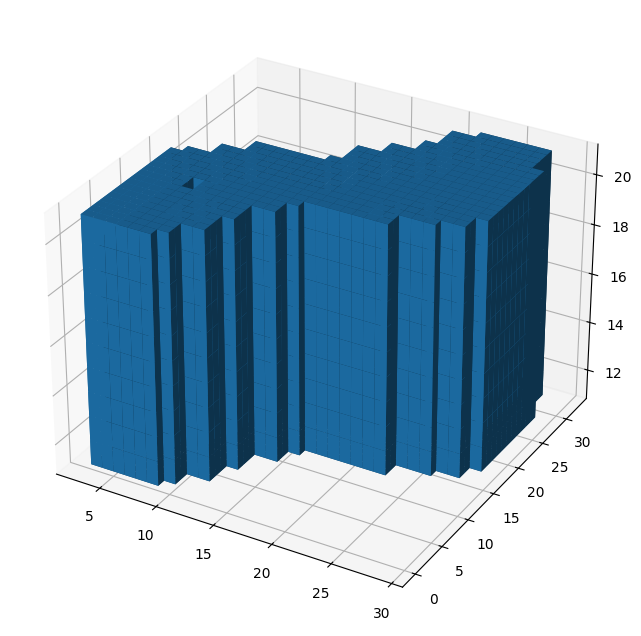

In [5]:
import matplotlib.pyplot as plt
import numpy as np

idx = np.where(labels == 8)[0][0]
V_bin = voxels[idx] > 0

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.voxels(V_bin)

plt.show()

#### Фильтрация и кубический симплекс

In [6]:
import numpy as np

voxels_bin = np.array([
    (v > 0).astype(np.uint8)
    for v in voxels
])

print(voxels_bin.shape)

(4000, 32, 32, 32)


HeightFiltration — это метод построения фильтрации для изображений, основанный на задании функции высоты на каждом вокселе. Формируется возрастающая последовательность множеств подуровней, включающих все точки изображения, для которых значение функции высоты не превышает заданного порога. При увеличении порога эти множества расширяются, задавая фильтрацию кубического комплекса.

In [15]:
from gtda.images import HeightFiltration

HF = HeightFiltration(
    direction=np.array([1, 1, 1]),
    n_jobs=-1
)

height_filtrations = HF.fit_transform(voxels_bin)

RadialFiltration основан на расстоянии от заданной центральной точки. Сначала выбирается центр, и каждому вокселю присваивается значение, равное его евклидову расстоянию до этого центра. После этого формируется последовательность подмножеств: сначала включаются точки, находящиеся ближе всего к центру, затем постепенно добавляются всё более удалённые. Изображение «растёт» в виде расширяющихся концентрических областей.

In [16]:
from gtda.images import RadialFiltration

HF = RadialFiltration(
    center=np.array([15, 15, 15])
)

height_filtrations = HF.fit_transform(voxels_bin)

В кубическом комплексе пространство строится из базовых элементов вида кубов. Каждый воксель рассматривается как единичный куб, а соседние элементы соединяются в соответствии с их смежностью, формируя структуру кубического комплекса.

In [17]:
from gtda.homology import CubicalPersistence

CP = CubicalPersistence(
    homology_dimensions=(0, 1, 2),
    n_jobs=-1
)

diagrams = CP.fit_transform(height_filtrations)

In [18]:
idx = np.where(labels == 8)[0][0]
CP.plot(diagrams, sample=idx)

#### Пайплайн

In [78]:
from sklearn.pipeline import make_pipeline, make_union
from gtda.diagrams import PersistenceEntropy, Scaler, Amplitude
from gtda.images import HeightFiltration, Binarizer

direction_list = [
    [1, 1, 1],
    [1, 1, 0],
    [1, 1, -1],

    [1, 0, 1],
    [1, 0, 0],
    [1, 0, -1],

    [1, -1, 1],
    [1, -1, 0],
    [1, -1, -1],

    [0, 1, 1],
    [0, 1, 0],
    [0, 1, -1],

    [0, 0, 1],
    [0, 0, -1],

    [0, -1, 1],
    [0, -1, 0],
    [0, -1, -1],

    [-1, 1, 1],
    [-1, 1, 0],
    [-1, 1, -1],

    [-1, 0, 1],
    [-1, 0, 0],
    [-1, 0, -1],

    [-1, -1, 1],
    [-1, -1, 0],
    [-1, -1, -1]
]

center_list = [
    [15, 15, 15],

    [5, 5, 5],
    [5, 5, 25],
    [5, 25, 5],
    [5, 25, 25],

    [25, 5, 5],
    [25, 5, 25],
    [25, 25, 5],
    [25, 25, 25],
]

# Список всех фильтров, которые будут применены
filtration_list = (
    [
        HeightFiltration(direction=np.array(direction), n_jobs=-1)
        for direction in direction_list
    ]
    + [RadialFiltration(center=np.array(center), n_jobs=-1) for center in center_list]
)

# Пайплайн для генерации диаграмм
diagram_steps = [
    [
        Binarizer(threshold=0.4, n_jobs=-1),
        filtration,
        CubicalPersistence(n_jobs=-1),
        Scaler(n_jobs=-1),
    ]
    for filtration in filtration_list
]

# Listing all metrics we want to use to extract diagram amplitudes
metric_list = [
    {"metric": "bottleneck", "metric_params": {}},
    {"metric": "wasserstein", "metric_params": {"p": 1}},
    {"metric": "wasserstein", "metric_params": {"p": 2}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 1, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 1, "n_layers": 2, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 1, "n_bins": 100}},
    {"metric": "landscape", "metric_params": {"p": 2, "n_layers": 2, "n_bins": 100}},
    {"metric": "betti", "metric_params": {"p": 1, "n_bins": 100}},
    {"metric": "betti", "metric_params": {"p": 2, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 1.6, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 1, "sigma": 3.2, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 2, "sigma": 1.6, "n_bins": 100}},
    {"metric": "heat", "metric_params": {"p": 2, "sigma": 3.2, "n_bins": 100}},
]

feature_union = make_union(
    *[PersistenceEntropy(nan_fill_value=-1)]
    + [Amplitude(**metric, n_jobs=-1) for metric in metric_list],
    n_jobs=-1
)

tda_union = make_union(
    *[make_pipeline(*diagram_step, feature_union) for diagram_step in diagram_steps],
    n_jobs=-1
)

In [79]:
from sklearn import set_config
set_config(display='diagram')

tda_union

FeatureUnion(n_jobs=-1,
             transformer_list=[('pipeline-1',
                                Pipeline(steps=[('binarizer',
                                                 Binarizer(n_jobs=-1,
                                                           threshold=0.4)),
                                                ('heightfiltration',
                                                 HeightFiltration(direction=array([1, 1, 1]),
                                                                  n_jobs=-1)),
                                                ('cubicalpersistence',
                                                 CubicalPersistence(n_jobs=-1)),
                                                ('scaler', Scaler(n_jobs=-1)),
                                                ('featureunion',
                                                 FeatureUnion(n_jobs=-1,
                                                              transformer_list=[('persistenceentr...
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 1,
                                                                                                          'sigma': 1.6},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-11',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 1,
                                                                                                          'sigma': 3.2},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-12',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 2,
                                                                                                          'sigma': 1.6},
                                                                                           n_jobs=-1)),
                                                                                ('amplitude-13',
                                                                                 Amplitude(metric='heat',
                                                                                           metric_params={'n_bins': 100,
                                                                                                          'p': 2,
                                                                                                          'sigma': 3.2},
                                                                                           n_jobs=-1))]))])), ...])

#### Извлечение и сохранение признаков

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    voxels,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

In [14]:
X_train_tda = tda_union.fit_transform(X_train)
X_train_tda.shape

c:\Users\USER\Desktop\topology-mnist3d\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


(3200, 980)

In [15]:
X_test_tda = tda_union.transform(X_test)
X_test_tda.shape

(800, 980)

In [ ]:
np.save("./data/extracted_features/cubical/X_train.npy", X_train_tda)
np.save("./data/extracted_features/cubical/X_test.npy", X_test_tda)

In [ ]:
np.save("./data/extracted_features/cubical/y_train.npy", y_train)
np.save("./data/extracted_features/cubical/y_test.npy", y_test)

#### Загрузка признаков

In [40]:
X_train_tda = np.load("./data/extracted_features/cubical/X_train.npy")
X_test_tda = np.load("./data/extracted_features/cubical/X_test.npy")

y_train = np.load("./data/extracted_features/cubical/y_train.npy")
y_test = np.load("./data/extracted_features/cubical/y_test.npy")

#### Классификация

##### Простая классификация

In [46]:
X_train = X_train_tda

In [ ]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test = train_test_split(X_test_tda, y_test, test_size=0.5, stratify=y_test, random_state=42, stratify=y_test)

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

F1 score:  0.7187885861958685
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        40
           1       0.93      0.93      0.93        40
           2       0.56      0.68      0.61        40
           3       0.72      0.53      0.61        40
           4       0.76      0.65      0.70        40
           5       0.66      0.57      0.61        40
           6       0.79      0.85      0.82        40
           7       0.76      0.70      0.73        40
           8       0.60      0.70      0.64        40
           9       0.69      0.78      0.73        40

    accuracy                           0.72       400
   macro avg       0.73      0.72      0.72       400
weighted avg       0.73      0.72      0.72       400

[[33  0  1  0  0  3  1  0  2  0]
 [ 0 37  1  0  1  0  1  0  0  0]
 [ 2  0 27  5  1  2  1  0  2  0]
 [ 5  1  4 21  1  1  1  1  5  0]
 [ 0  1  2  1 26  1  1  2  2  4]
 [ 0  0  4  1  2 23  3  0  7  0]
 [ 1  0  5  0

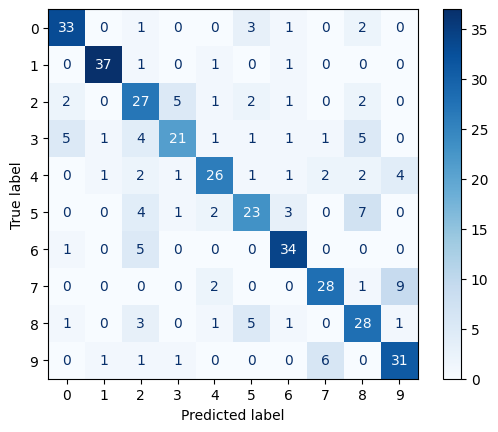

In [49]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, cmap=plt.cm.Blues)
print(disp.confusion_matrix)
	
plt.show()

##### Оптимизация гиперпараметров

In [50]:
import ml.optuna_search
importlib.reload(ml.optuna_search)

<module 'ml.optuna_search' from 'c:\\Users\\USER\\Desktop\\topology-mnist3d\\ml\\optuna_search.py'>

In [ ]:
model_list = ["XGBClassifier"]
search = ml.optuna_search.ModelOptimization(model_list)
search.fit(X_train, y_train, X_val, y_val, X_test, y_test, n_trials=50, n_startup_trials=10)


XGBClassifier hyperoptimization


  0%|          | 0/50 [00:00<?, ?it/s]

In [48]:
clf = search.best_models[0]
search.best_models_f1_test

[0.8099697659070992]

In [50]:
clf

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8738860269453518, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03469160448231056,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=-1,
              num_parallel_tree=None, ...)

F1 score:  0.7823460059552328
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        40
           1       0.95      0.93      0.94        40
           2       0.78      0.78      0.78        40
           3       0.72      0.65      0.68        40
           4       0.67      0.85      0.75        40
           5       0.86      0.62      0.72        40
           6       0.93      0.93      0.93        40
           7       0.76      0.72      0.74        40
           8       0.65      0.78      0.70        40
           9       0.78      0.72      0.75        40

    accuracy                           0.78       400
   macro avg       0.79      0.78      0.78       400
weighted avg       0.79      0.78      0.78       400

[[34  0  1  0  1  0  1  0  3  0]
 [ 0 37  1  0  1  0  0  1  0  0]
 [ 3  0 31  1  2  2  0  0  1  0]
 [ 1  0  1 26  2  1  0  0  7  2]
 [ 0  0  1  0 34  0  0  1  3  1]
 [ 2  0  1  4  2 25  2  2  1  1]
 [ 0  0  2  1

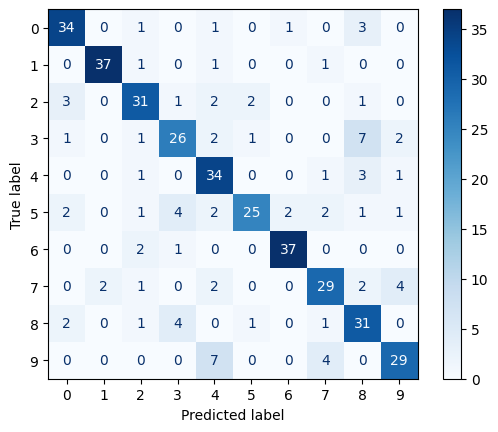

In [49]:
y_pred = clf.predict(X_val)

print("F1 score: ", f1_score(y_val, y_pred, average="macro"))
print(classification_report(y_val, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_val, y_val, cmap=plt.cm.Blues)
print(disp.confusion_matrix)
	
plt.show()

F1 score:  0.8099697659070992
              precision    recall  f1-score   support

           0       0.82      0.93      0.87        40
           1       0.93      0.93      0.93        40
           2       0.68      0.70      0.69        40
           3       0.85      0.72      0.78        40
           4       0.84      0.80      0.82        40
           5       0.74      0.78      0.76        40
           6       0.88      0.88      0.88        40
           7       0.89      0.78      0.83        40
           8       0.69      0.72      0.71        40
           9       0.81      0.88      0.84        40

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400

[[37  0  1  0  0  0  1  0  1  0]
 [ 0 37  2  0  1  0  0  0  0  0]
 [ 3  0 28  3  0  3  1  0  2  0]
 [ 3  1  2 29  1  2  0  1  1  0]
 [ 0  0  1  0 32  2  1  0  1  3]
 [ 0  0  1  2  0 31  0  0  6  0]
 [ 0  0  4  0

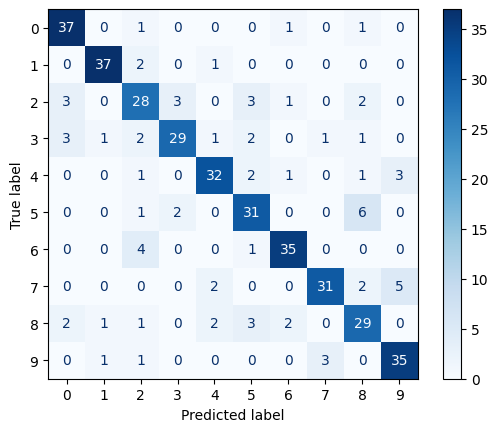

In [51]:
y_pred = clf.predict(X_test)

print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap=plt.cm.Blues)
print(disp.confusion_matrix)
	
plt.show()

In [70]:
import pickle
from pathlib import Path

model_path = Path("./ml/models/XGB_81.pkl")

with open (model_path,'wb') as f:
    pickle.dump(clf, f)

In [73]:
import pickle
from pathlib import Path

model_path = Path("./ml/models/XGB_81.pkl")

with open (model_path,'rb') as f:
    clf2 = pickle.load(f)

#### Тестирование на устойчивость

In [63]:
import utils.utils
import importlib

importlib.reload(utils.utils)

sigmas = [0.01, 0.03, 0.05, 0.08]
f1_scores = np.empty_like(sigmas)
noisy_clouds = []
noised_voxels = []

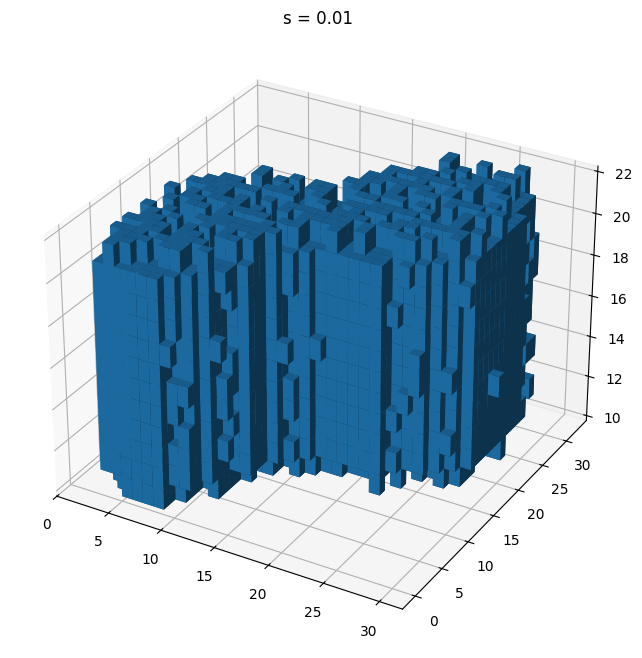

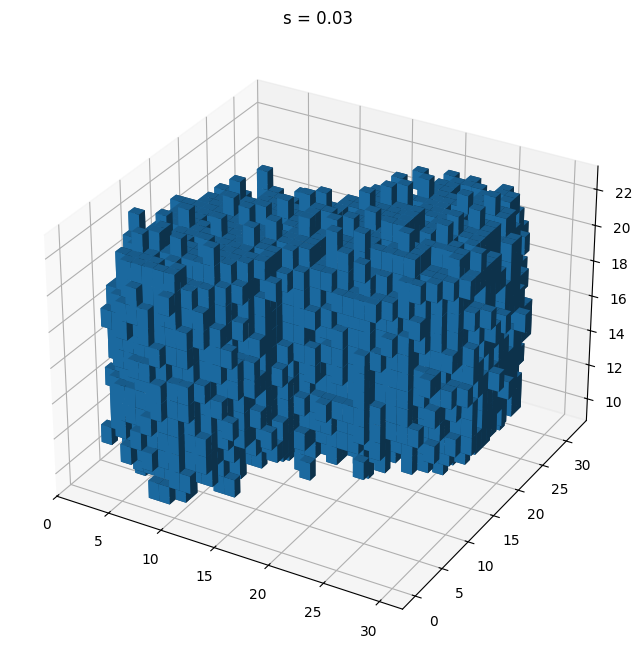

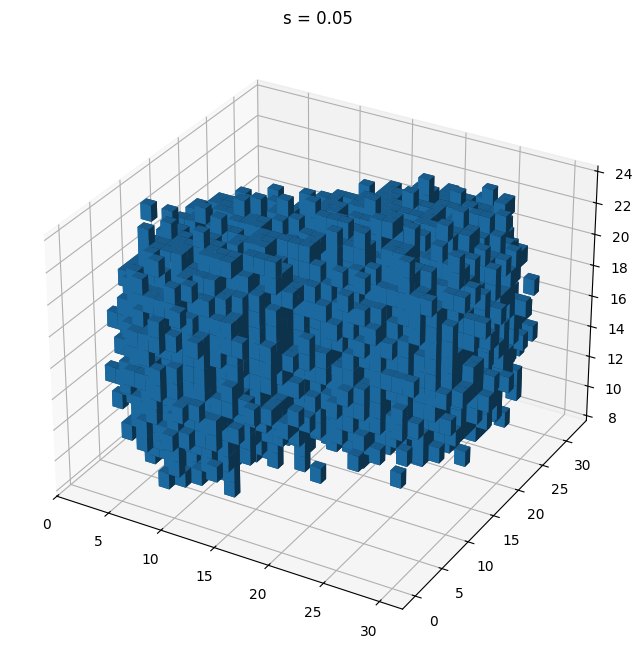

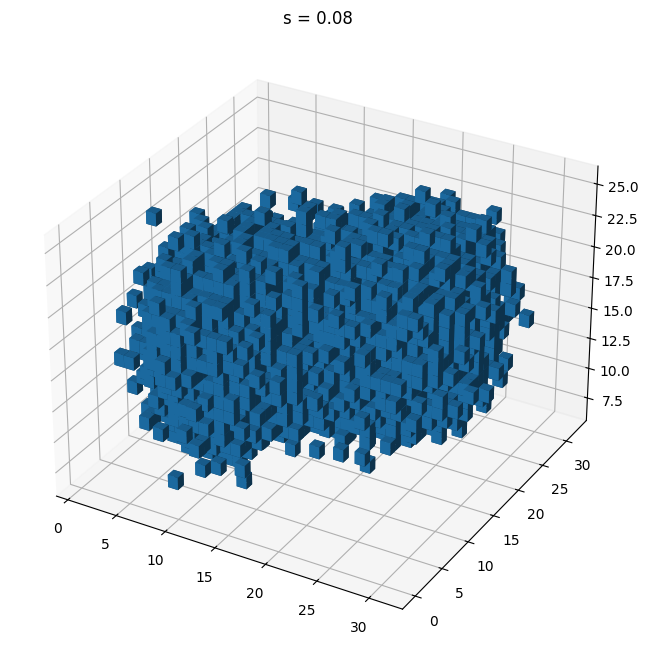

In [64]:
for s in sigmas:
    _noisy_clouds = utils.utils.add_gaussian_noise(point_clouds, sigma=s)
    _noised_voxels = [VoxelGrid(cloud, x_y_z=[32, 32, 32]).vector for cloud in _noisy_clouds]

    idx = np.where(labels == 8)[0][0]
    V_bin = _noised_voxels[idx] > 0
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection='3d')
    ax.voxels(V_bin)
    plt.title(f"s = {s}")
    plt.show()

    noisy_clouds.append(_noisy_clouds)
    noised_voxels.append(_noised_voxels)

In [76]:
def get_tests(X, y):
    _, X_test, _, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=labels
    )

    X_test_tda = tda_union.transform(X_test)
    X_test_tda.shape

    _, X_test, _, y_test = train_test_split(
        X_test,
        y_test,
        test_size=0.5,
        stratify=y_test,
        random_state=42
    )

    return X_test, y_test

In [80]:
for i in range (len(noised_voxels)-1):
    X_test_noised, y_test_noised = get_tests(noised_voxels[i], labels)
    y_pred = clf.predict(X_test_noised)

    print(f"Results for sigma = {sigmas[i]}")
    f1 = f1_score(y_test_noised, y_pred, average="macro")
    f1_scores[i] = f1
    print("F1 score: ", f1)
    print(classification_report(y_test_noised, y_pred))

    disp = ConfusionMatrixDisplay.from_estimator(clf, X_test_noised, y_test_noised, cmap=plt.cm.Blues)
    print(disp.confusion_matrix)
        
    plt.show()

NotFittedError: This Binarizer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
plt.plot(sigmas[:-1], f1_scores, marker='o')
plt.xlabel("Уровень шума (Sigma)")
plt.ylabel("F1 Score")
plt.title("Изменение точности с увеличением шума")
plt.grid(True)
plt.show()